In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore') 

In [5]:
df = pd.read_csv(r"C:\Users\prati\Downloads\exchange_rate.csv")

In [6]:
df.iloc[:, 0] = pd.to_datetime(df.iloc[:, 0], dayfirst=True, errors="coerce")
df = df.dropna(subset=[df.columns[0]])
df.set_index(df.columns[0], inplace=True)

In [7]:
series = df.iloc[:, 0].astype(float)

In [8]:
series = series.interpolate(method='time')

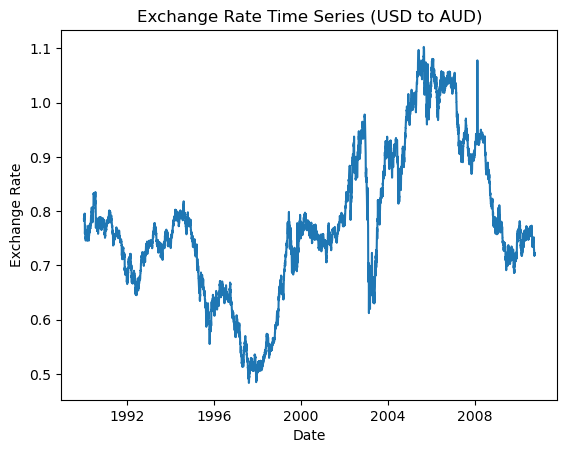

In [9]:
plt.figure()
plt.plot(series)
plt.title("Exchange Rate Time Series (USD to AUD)")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.show()

In [10]:
train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]

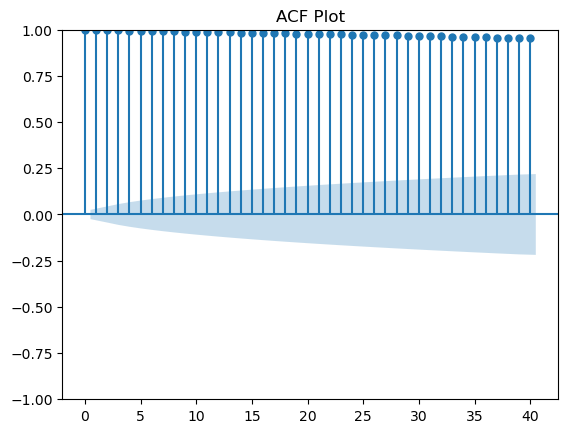

In [11]:
plt.figure()
plot_acf(train, ax=plt.gca(), lags=40)
plt.title("ACF Plot")
plt.show()

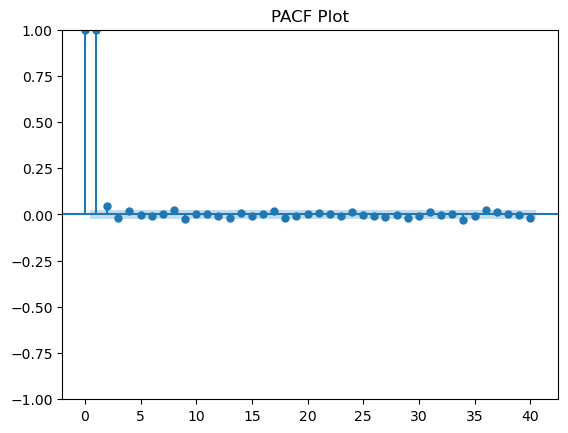

In [12]:
plt.figure()
plot_pacf(train, ax=plt.gca(), lags=40)
plt.title("PACF Plot")
plt.show()

In [13]:
arima_model = ARIMA(train, order=(1, 1, 1))
arima_fit = arima_model.fit()

In [14]:
arima_forecast = arima_fit.forecast(steps=len(test))

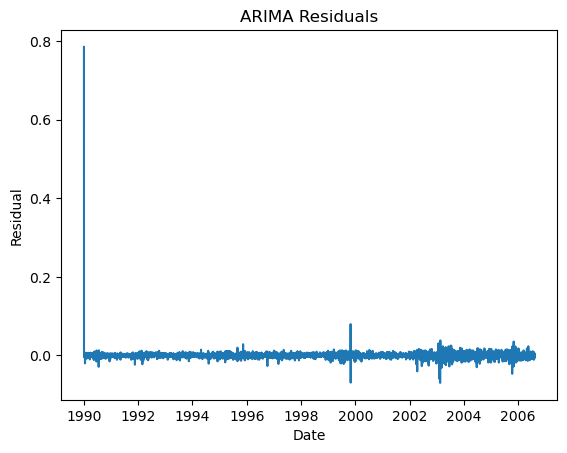

In [15]:
residuals = arima_fit.resid
plt.figure()
plt.plot(residuals)
plt.title("ARIMA Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.show()

In [16]:
es_model = ExponentialSmoothing(train, trend="add", seasonal=None)
es_fit = es_model.fit()
es_forecast = es_fit.forecast(len(test))

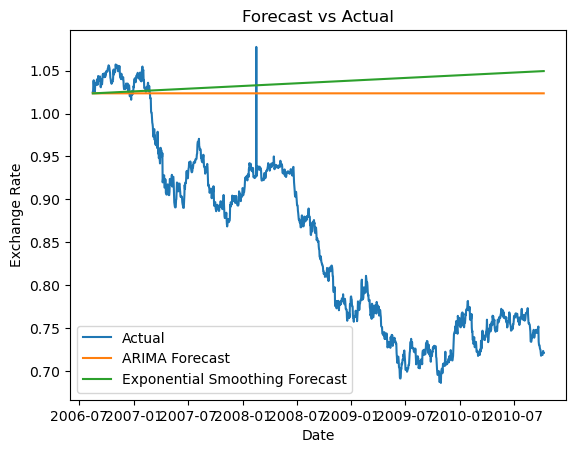

In [17]:
plt.figure()
plt.plot(test.index, test.values, label="Actual")
plt.plot(test.index, arima_forecast.values, label="ARIMA Forecast")
plt.plot(test.index, es_forecast.values, label="Exponential Smoothing Forecast")
plt.title("Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

In [18]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

metrics = {
    "Model": ["ARIMA", "Exponential Smoothing"],
    "MAE": [
        mean_absolute_error(test, arima_forecast),
        mean_absolute_error(test, es_forecast),
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(test, arima_forecast)),
        np.sqrt(mean_squared_error(test, es_forecast)),
    ],
    "MAPE": [
        mape(test.values, arima_forecast.values),
        mape(test.values, es_forecast.values),
    ],
}

metrics_df = pd.DataFrame(metrics)
metrics_df

,Model,MAE,RMSE,MAPE
0,ARIMA,0.177710,0.205437,22.797966
1,Exponential Smoothing,0.190268,0.220079,24.412001


In [19]:
print("""Model Comparison
ARIMA
Advantages:
Better accuracy across all metrics
Handles autocorrelation explicitly
Strong theoretical foundation

Limitations:
Assumes linear structure
Sensitive to parameter choice
Limited performance in high volatility periods

Exponential Smoothing
Advantages:
Simpler and faster
Good for smooth trends
Easy to interpret

Limitations:
Weaker performance here
Less responsive to complex dynamics
Assumes smoother behavior than financial data exhibits""")

Model Comparison
ARIMA
Advantages:
Better accuracy across all metrics
Handles autocorrelation explicitly
Strong theoretical foundation

Limitations:
Assumes linear structure
Sensitive to parameter choice
Limited performance in high volatility periods

Exponential Smoothing
Advantages:
Simpler and faster
Good for smooth trends
Easy to interpret

Limitations:
Weaker performance here
Less responsive to complex dynamics
Assumes smoother behavior than financial data exhibits


In [20]:
print("""The exchange rate series is non-stationary and volatile
ARIMA(1,1,1) provided better forecasting accuracy
Exponential smoothing was competitive but less precise
Both models struggle with sudden market shocks

ARIMA performed best for this dataset based on MAE, RMSE, and MAPE.

However:
Neither model fully captures financial market complexity
More advanced models (e.g., SARIMA, GARCH, LSTM) could improve performance""")

The exchange rate series is non-stationary and volatile
ARIMA(1,1,1) provided better forecasting accuracy
Exponential smoothing was competitive but less precise
Both models struggle with sudden market shocks

ARIMA performed best for this dataset based on MAE, RMSE, and MAPE.

However:
Neither model fully captures financial market complexity
More advanced models (e.g., SARIMA, GARCH, LSTM) could improve performance


In [22]:
print("""The time series shows non-stationary behavior with volatility. 
ACF and PACF analysis suggested an ARIMA(1,1,1) model. 
Forecast evaluation showed ARIMA outperformed exponential smoothing in terms of MAE, RMSE, and MAPE. 
However, both models struggled with sudden market shocks.""")

The time series shows non-stationary behavior with volatility. 
ACF and PACF analysis suggested an ARIMA(1,1,1) model. 
Forecast evaluation showed ARIMA outperformed exponential smoothing in terms of MAE, RMSE, and MAPE. 
However, both models struggled with sudden market shocks.
